In [1]:
%cd ..
import numpy as np
from src.constructors.asianoption import AsianOption
from src.monte_carlo.mc_pricer import MCPricer
import matplotlib.pyplot as plt

/Users/filipporonzino/anaconda3/lib/python3.11/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/Users/filipporonzino/Documents/bocconi/thesis/bsc-thesis/bsc-thesis


In [2]:
# Params
S0 = 100        # Initial stock price
K = 100         # Strike price
T = 1           # Time to maturity (in years)
r = 0.05        # Risk-free rate
sigma = 0.2     # Volatility
n_steps = 252   # Number of time steps
n_sims = 10000  # Number of Monte Carlo simulations

asian_option = AsianOption(S0, K, T, r, sigma, n_steps, 'arithmetic')
pricer = MCPricer(n_sims, n_steps)

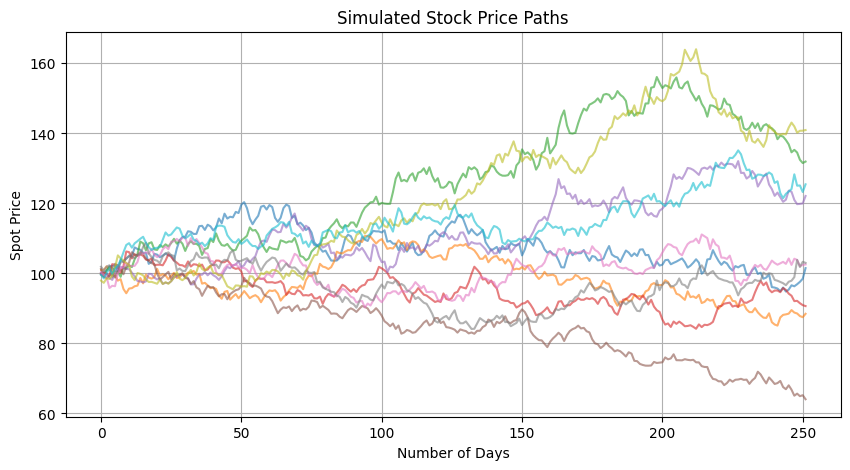

In [3]:
# Plot 10 sample paths
paths = pricer.generate_paths(asian_option)

plt.figure(figsize=(10, 5))
for i in range(10):
    plt.plot(range(n_steps), paths[i], alpha=0.6)

plt.xlabel("Number of Days")
plt.ylabel("Spot Price")
plt.title("Simulated Stock Price Paths")
plt.grid(True)
plt.show()

In [5]:
# Check correlation between the arithmetic and geometric Asian options
pricer = MCPricer(n_sims, n_steps)
asian_option_geometric = AsianOption(S0, K, T, r, sigma, n_steps, 'geometric')
asian_option_arithmetic = AsianOption(S0, K, T, r, sigma, n_steps, 'arithmetic')

price_geometric = pricer.price(asian_option_geometric)
price_arithmetic = pricer.price(asian_option_arithmetic)

print(f'Geometric Asian option price: {price_geometric:.2f}')
print(f'Arithmetic Asian option price: {price_arithmetic:.2f}')

paths = pricer.generate_paths(asian_option_arithmetic)

payoffs_arithmetic = asian_option_arithmetic.payoff(paths)
payoffs_geometric = asian_option_geometric.payoff(paths)

correlation = np.corrcoef(payoffs_arithmetic, payoffs_geometric)[0, 1]

print(f'Correlation between arithmetic and geometric Asian option payoffs: {correlation:.4f}')

Geometric Asian option price: 5.53
Arithmetic Asian option price: 5.96
Correlation between arithmetic and geometric Asian option payoffs: 0.9996


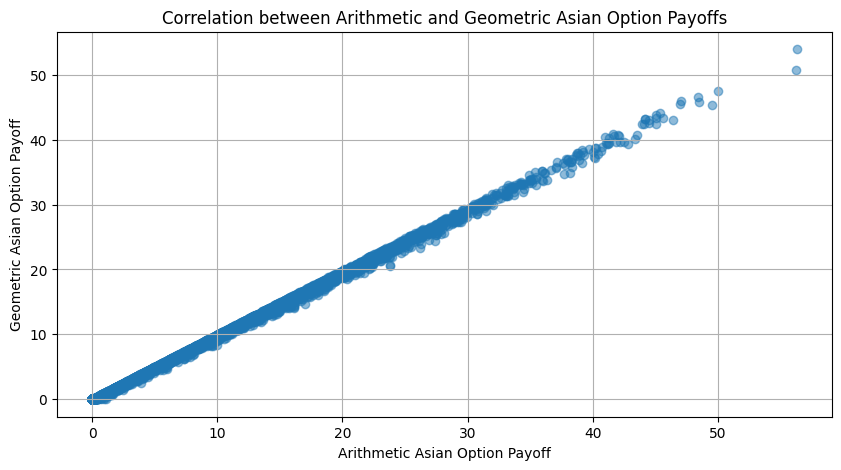

In [6]:
# Plot the payoffs to check the correlation
plt.figure(figsize=(10, 5))
plt.scatter(payoffs_arithmetic, payoffs_geometric, alpha=0.5)
plt.xlabel("Arithmetic Asian Option Payoff")
plt.ylabel("Geometric Asian Option Payoff")
plt.title("Correlation between Arithmetic and Geometric Asian Option Payoffs")
plt.grid(True)
plt.show()

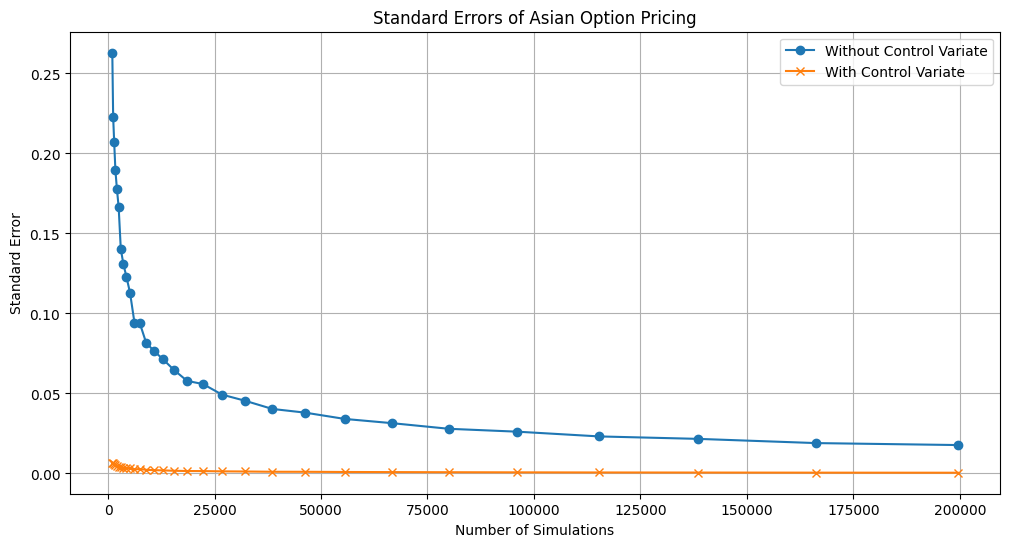

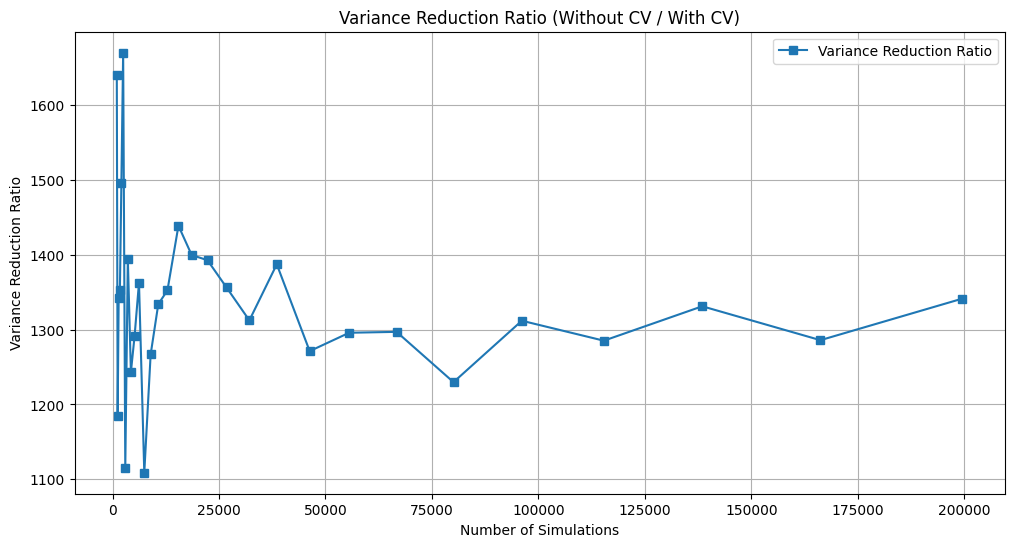

In [8]:
def test_control_variate(S0, K, T, r, sigma, n_steps, n_sims_list):
    std_errors_no_cv = []
    std_errors_cv = []
    variance_reduction_ratios = []

    for n_sims in n_sims_list:
        option_arithmetic = AsianOption(S0, K, T, r, sigma, n_steps, option_type='arithmetic')
        option_geometric = AsianOption(S0, K, T, r, sigma, n_steps, option_type='geometric')
        pricer = MCPricer(n_sims=n_sims, n_steps=n_steps)

        # Compute standard errors
        std_error_no_cv = pricer.std_error(option_arithmetic, use_control_variate=False)
        std_error_cv = pricer.std_error(option_arithmetic, use_control_variate=True)

        std_errors_no_cv.append(std_error_no_cv)
        std_errors_cv.append(std_error_cv)

        # Variance Reduction Ratio
        variance_reduction_ratio = std_error_no_cv ** 2 / std_error_cv ** 2
        variance_reduction_ratios.append(variance_reduction_ratio)

    # Plot Standard Errors
    plt.figure(figsize=(12, 6))
    plt.plot(n_sims_list, std_errors_no_cv, label='Without Control Variate', marker='o')
    plt.plot(n_sims_list, std_errors_cv, label='With Control Variate', marker='x')
    plt.title('Standard Errors of Asian Option Pricing')
    plt.xlabel('Number of Simulations')
    plt.ylabel('Standard Error')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plot Variance Reduction Ratio
    plt.figure(figsize=(12, 6))
    plt.plot(n_sims_list, variance_reduction_ratios, label='Variance Reduction Ratio', marker='s')
    plt.title('Variance Reduction Ratio (Without CV / With CV)')
    plt.xlabel('Number of Simulations')
    plt.ylabel('Variance Reduction Ratio')
    plt.legend()
    plt.grid(True)
    plt.show()


# Example parameters
S0 = 100  # Initial stock price
K = 100   # Strike price
T = 1.0   # Time to maturity (1 year)
r = 0.05  # Risk-free rate
sigma = 0.2  # Volatility
n_steps = 252  # Number of time steps
n_sims_list = np.unique(np.logspace(3, 5.3, 30, dtype=int))  # 30 points from 1,000 to ~200,000

test_control_variate(S0, K, T, r, sigma, n_steps, n_sims_list)